# Local friendliness violations with Quantum Computer Agents
This notebook guides through the full pipeline of:
1. Circuit construction
2. Noiseless (ideal) simulation
3. Transpilation for IBM quantum hardware
4. Fake-hardware simulations
5. Real hardware runs on IBM-Torino

In [13]:
# Standard library
import os
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# IBM Qiskit imports:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino

np.random.seed(42)

# Plot style
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 11
})

# project paths
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data"
PATH_FAKE = DATA_PATH / "data_fake_hardware"
PATH_NOISELESS = DATA_PATH / "data_noiseless_simulation"
PATH_REAL = DATA_PATH / "data_real_hardware"

PosixPath('/Users/joshua/PycharmProjects/masters_thesis_project/notebooks')

## 1. Circuit construction
In this project we work with 3 different agents, which are defined in detail in the paper.
- Reflex agent
- Guessing agent
- Betting agent
To show 'Local friendliness' violations the following inequality is used:
$$
S = - E_{11} + E_{11} - E_{21} - E_{22} - 2
$$
Extended Wigner's friend scenario (EWFS) circuits including one of the agents as the friend Charlie are built using Qiskit to later be run on quantum computers. Specifically, the minimal scenario with only one friend Charlie is implemented (described in arXiv:2209.08491v4).

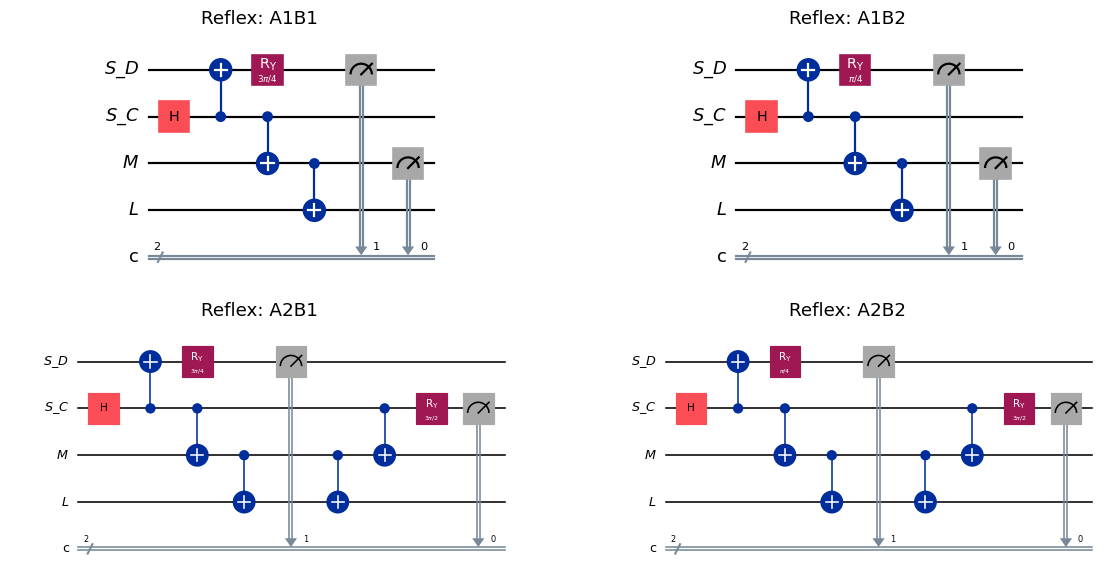

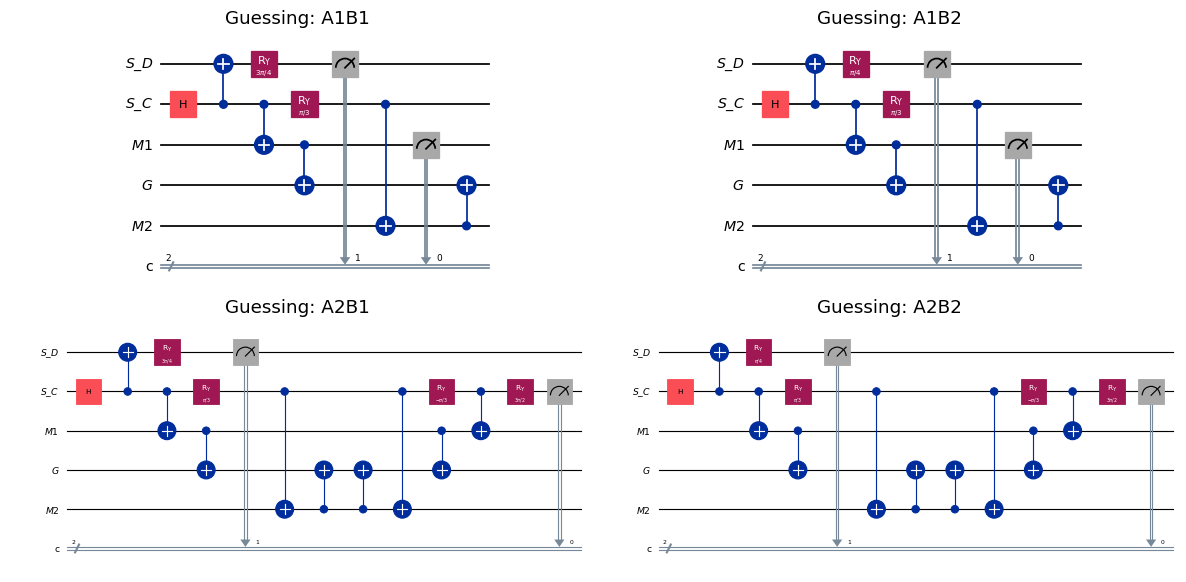

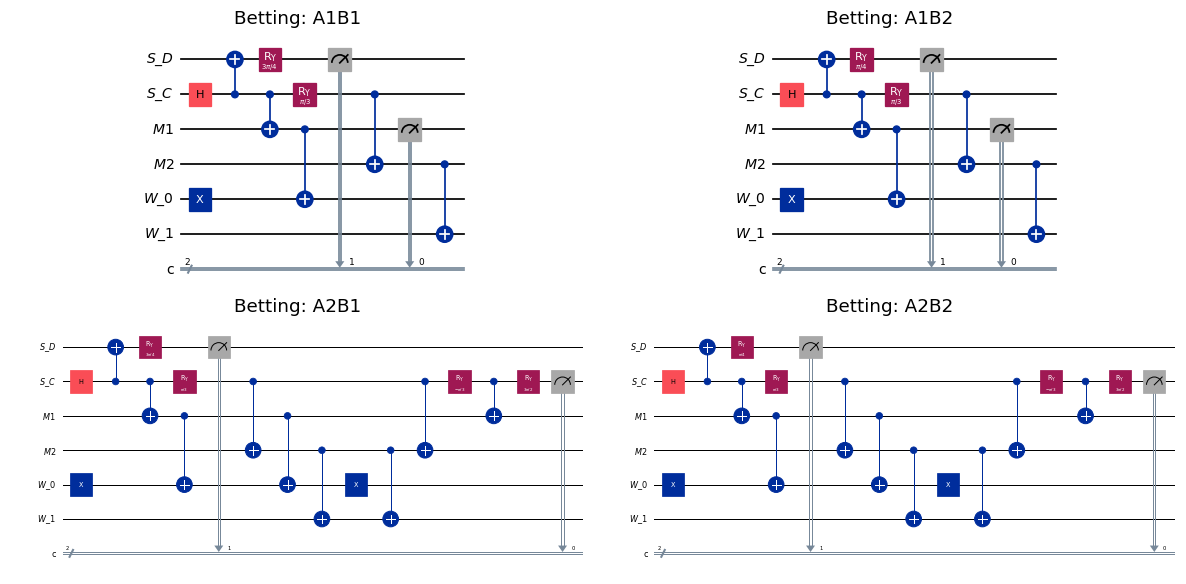

In [14]:
# Import of agents
from ewfs.agents import guessing_agent
from ewfs.agents import betting_agent
from ewfs.agents import reflex_agent

# LF-inequality
SETTINGS = [("A1B1", 1, 1), ("A1B2", 1, 2), ("A2B1", 2, 1), ("A2B2", 2, 2)]

# optimal angles
alpha = 3.0 * np.pi / 2.0
beta1 = 3.0 * np.pi / 4.0
beta2 = 1.0 * np.pi / 4.0

AGENTS = [
    ("Reflex", reflex_agent.build_measurement),
    ("Guessing", guessing_agent.build_measurement),
    ("Betting", betting_agent.build_measurement),
]

def plot_agent_circuits(agent_name, build_fn):
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes = axes.flatten()

    for ax, (label, A, B) in zip(axes, SETTINGS):
        qc = build_fn(A, B, alpha, beta1, beta2)
        qc.draw(output="mpl", ax=ax, fold=-1)
        ax.set_title(f"{agent_name}: {label}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

for name, build_fn in AGENTS:
    plot_agent_circuits(name, build_fn)

# 2. Noiseless (ideal) simulation
An ideal simulation assuming no noise should and using the optimal angles should give the maximum violation which is given by
$$
S_{\mathrm{max}} = 2(\sqrt{2} -1) \approx 0.83
$$


In [32]:
from ewfs.noiseless_simulation import run_noiseless_simulation

run_noiseless_simulation(shots=100_000,save=False, make_plots=False);


Reflex Agent (noiseless simulation): S_SB ≈ 0.823
Guessing Agent (noiseless simulation): S_SB ≈ 0.830
Betting Agent (noiseless simulation): S_SB ≈ 0.832


# 3. Transpilation for IBM
To run the circuits on real quantum hardware, the circuit needs to be transpiled to match the architecture of a chosen device.
In this project, we run on the IBM-Torino device, which is a 133 qubit superconducting quantum computer from IBM.

IBM-Torino's native gates, which describes a universal basis, are:
$$
\{ R_Z(\theta),\, SX,\, X,\, CZ \}
$$

Therefore we can translate our circuit into IBM-Torino's native gates using the following relations:
$$
\begin{aligned}
H &= R_Z(\pi)\, SX\, R_Z(\pi), \\[6pt]
X &= X = SX^2, \\[6pt]
R_Y(\theta)
  &= R_Z(\pi)\, SX\, R_Z(\theta)\, SX, \\[6pt]
\mathrm{CNOT}_{c,t}
  &= (I \otimes H)\,
     CZ_{c,t}\,
     (I \otimes H).
\end{aligned}
$$

Furthermore, the IBM-devices are not fully connected, meaning not all qubits can be connected using multi qubit gates. The so-called 'coupling map' of the IBM-Torino hardware device can be accessed via the IBM Quantum platform: quantum.cloud.ibm.com
This coupling map also includes specific calibration values, for example two-qubit errors or readout errors, which are the two that contribute to the noise the most. By comparing the agent connectivity with the coupling map of IBM-Torino one can manually set the qubits to an optimal position. Here it is best to choose a layout with small readout and two-qubit gate error. A screenshot of the coupling map from IBM-Torino on 24/02/2026 15:21pm is included, aswell as one example of a transpiled circuit for the Betting agent's A=1 and B=1 settings.

Note that it is convenitent to build circuits that match the connectivity of the IBM device one is using. If one wants to transpile a circuit that does not match the coupling map, SWAP gates are needed, which swap the states for neighboring qubits, which resluts in more gates and therefore more noise overall.

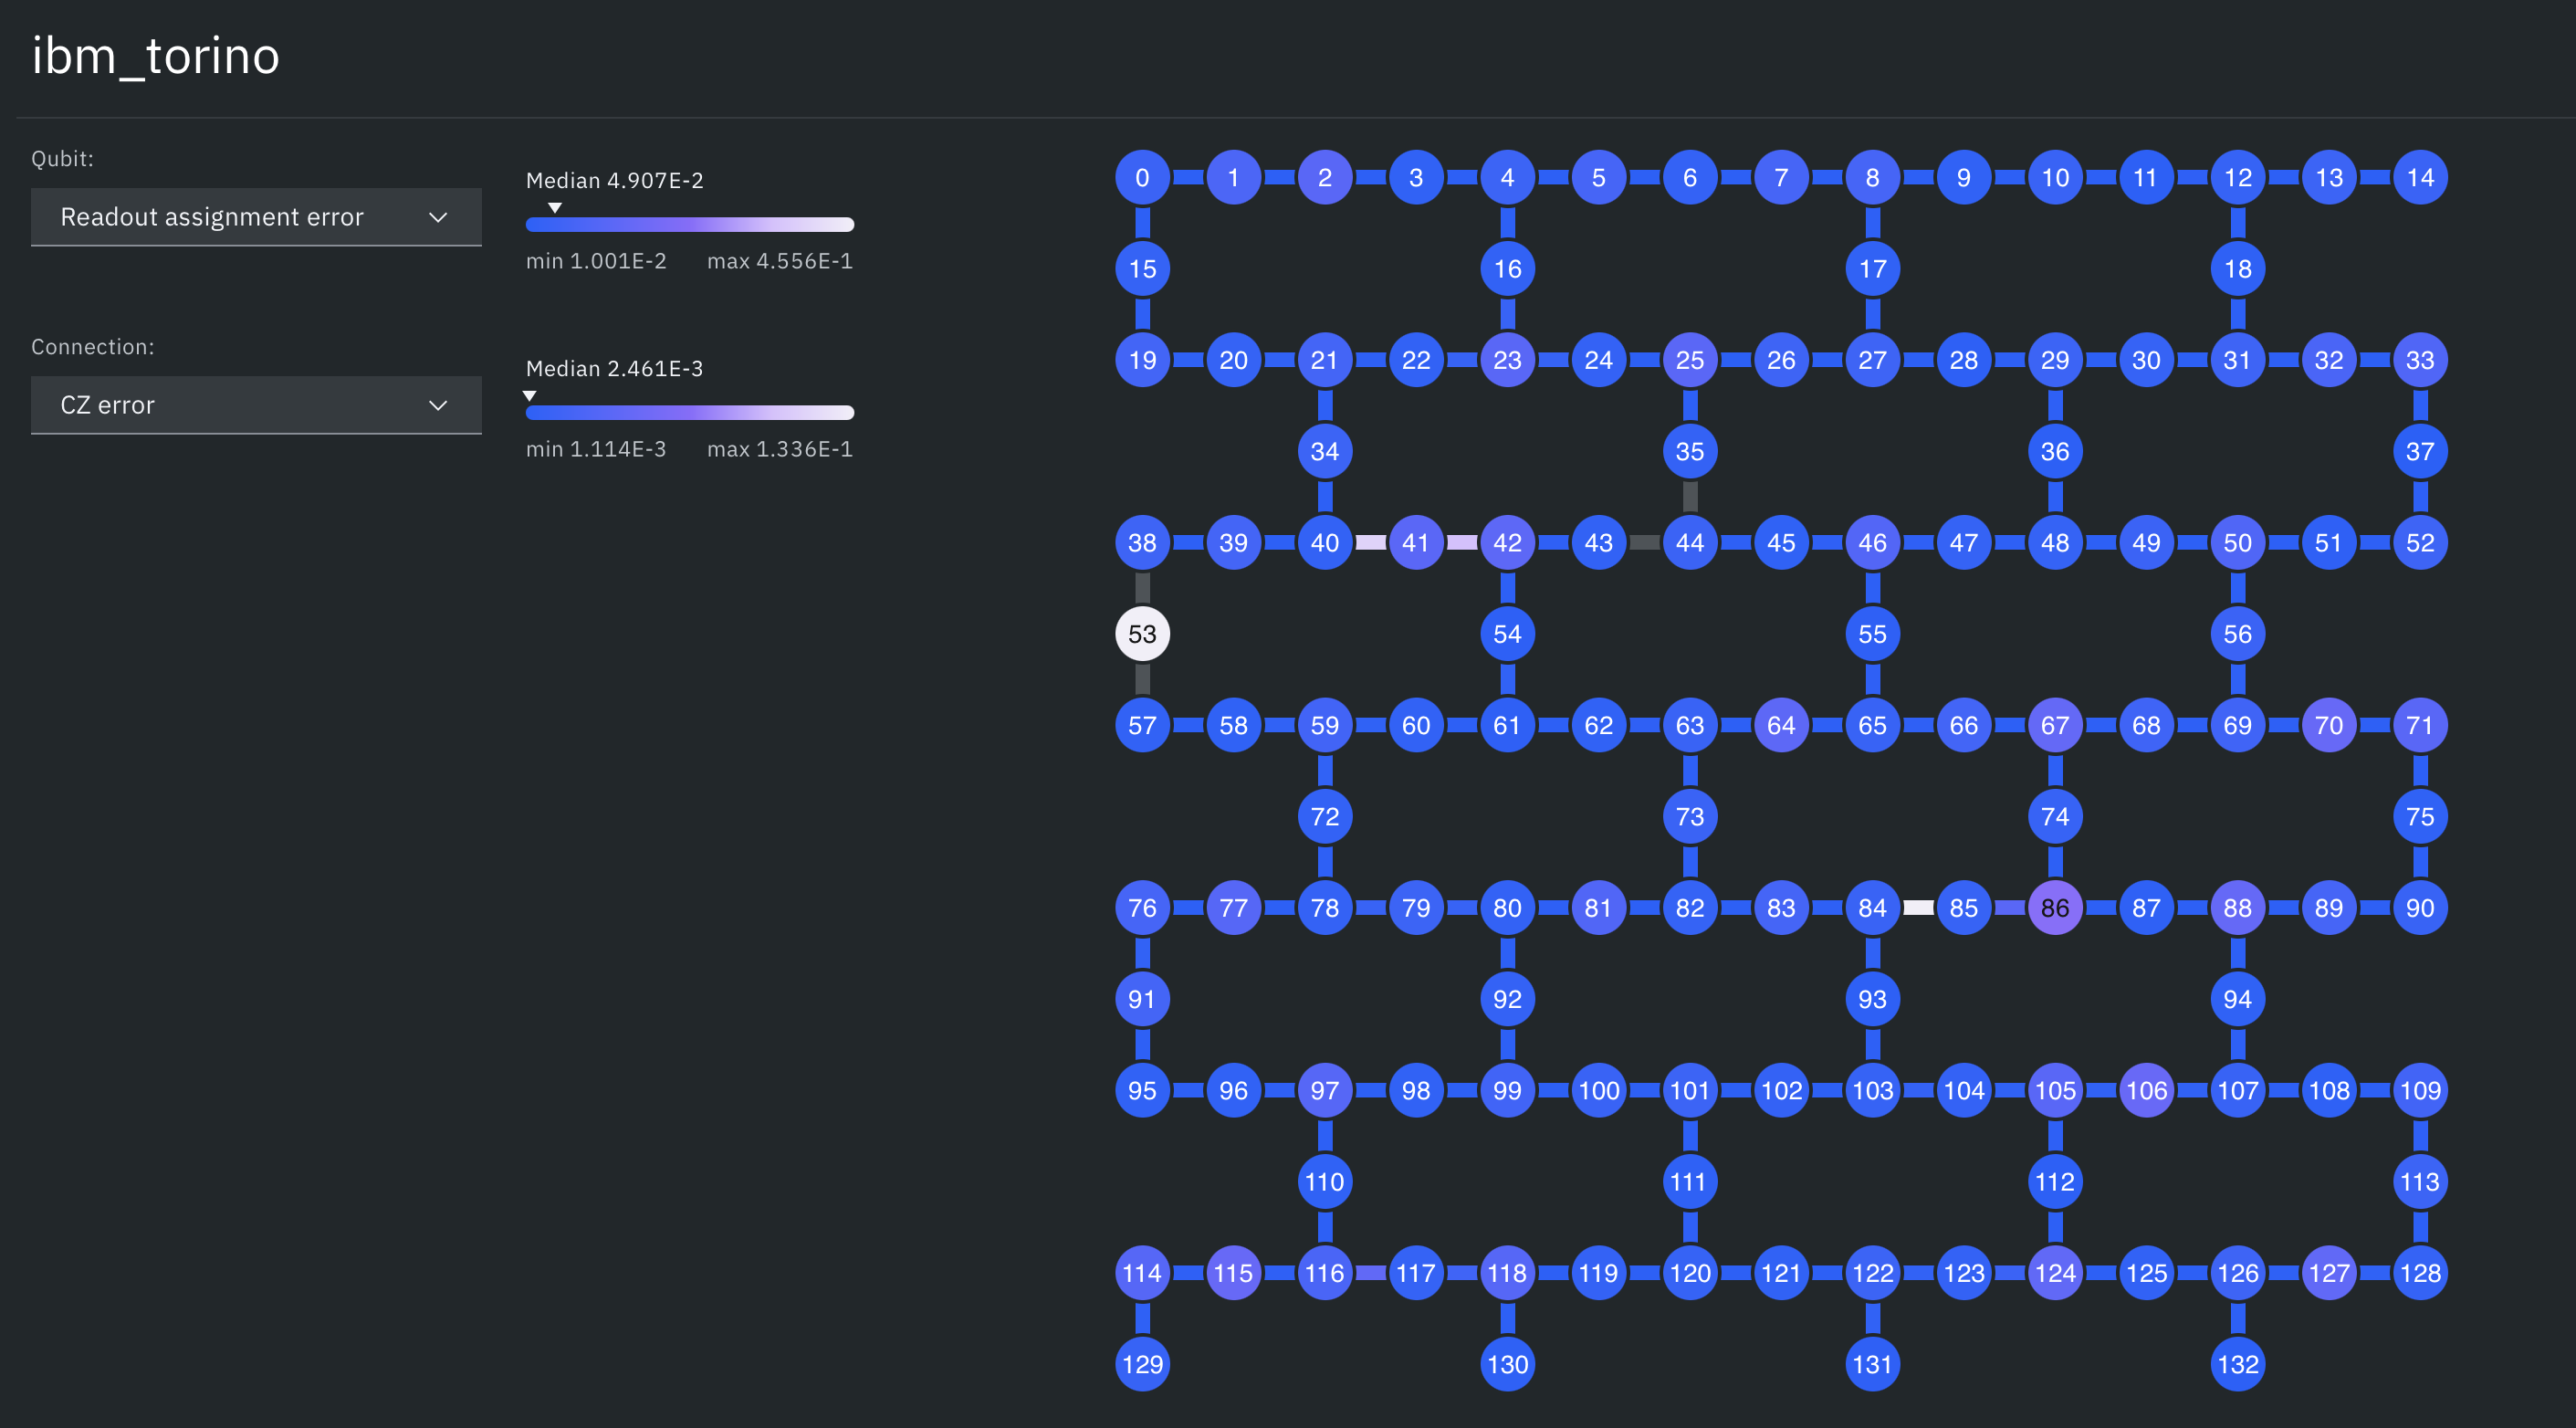

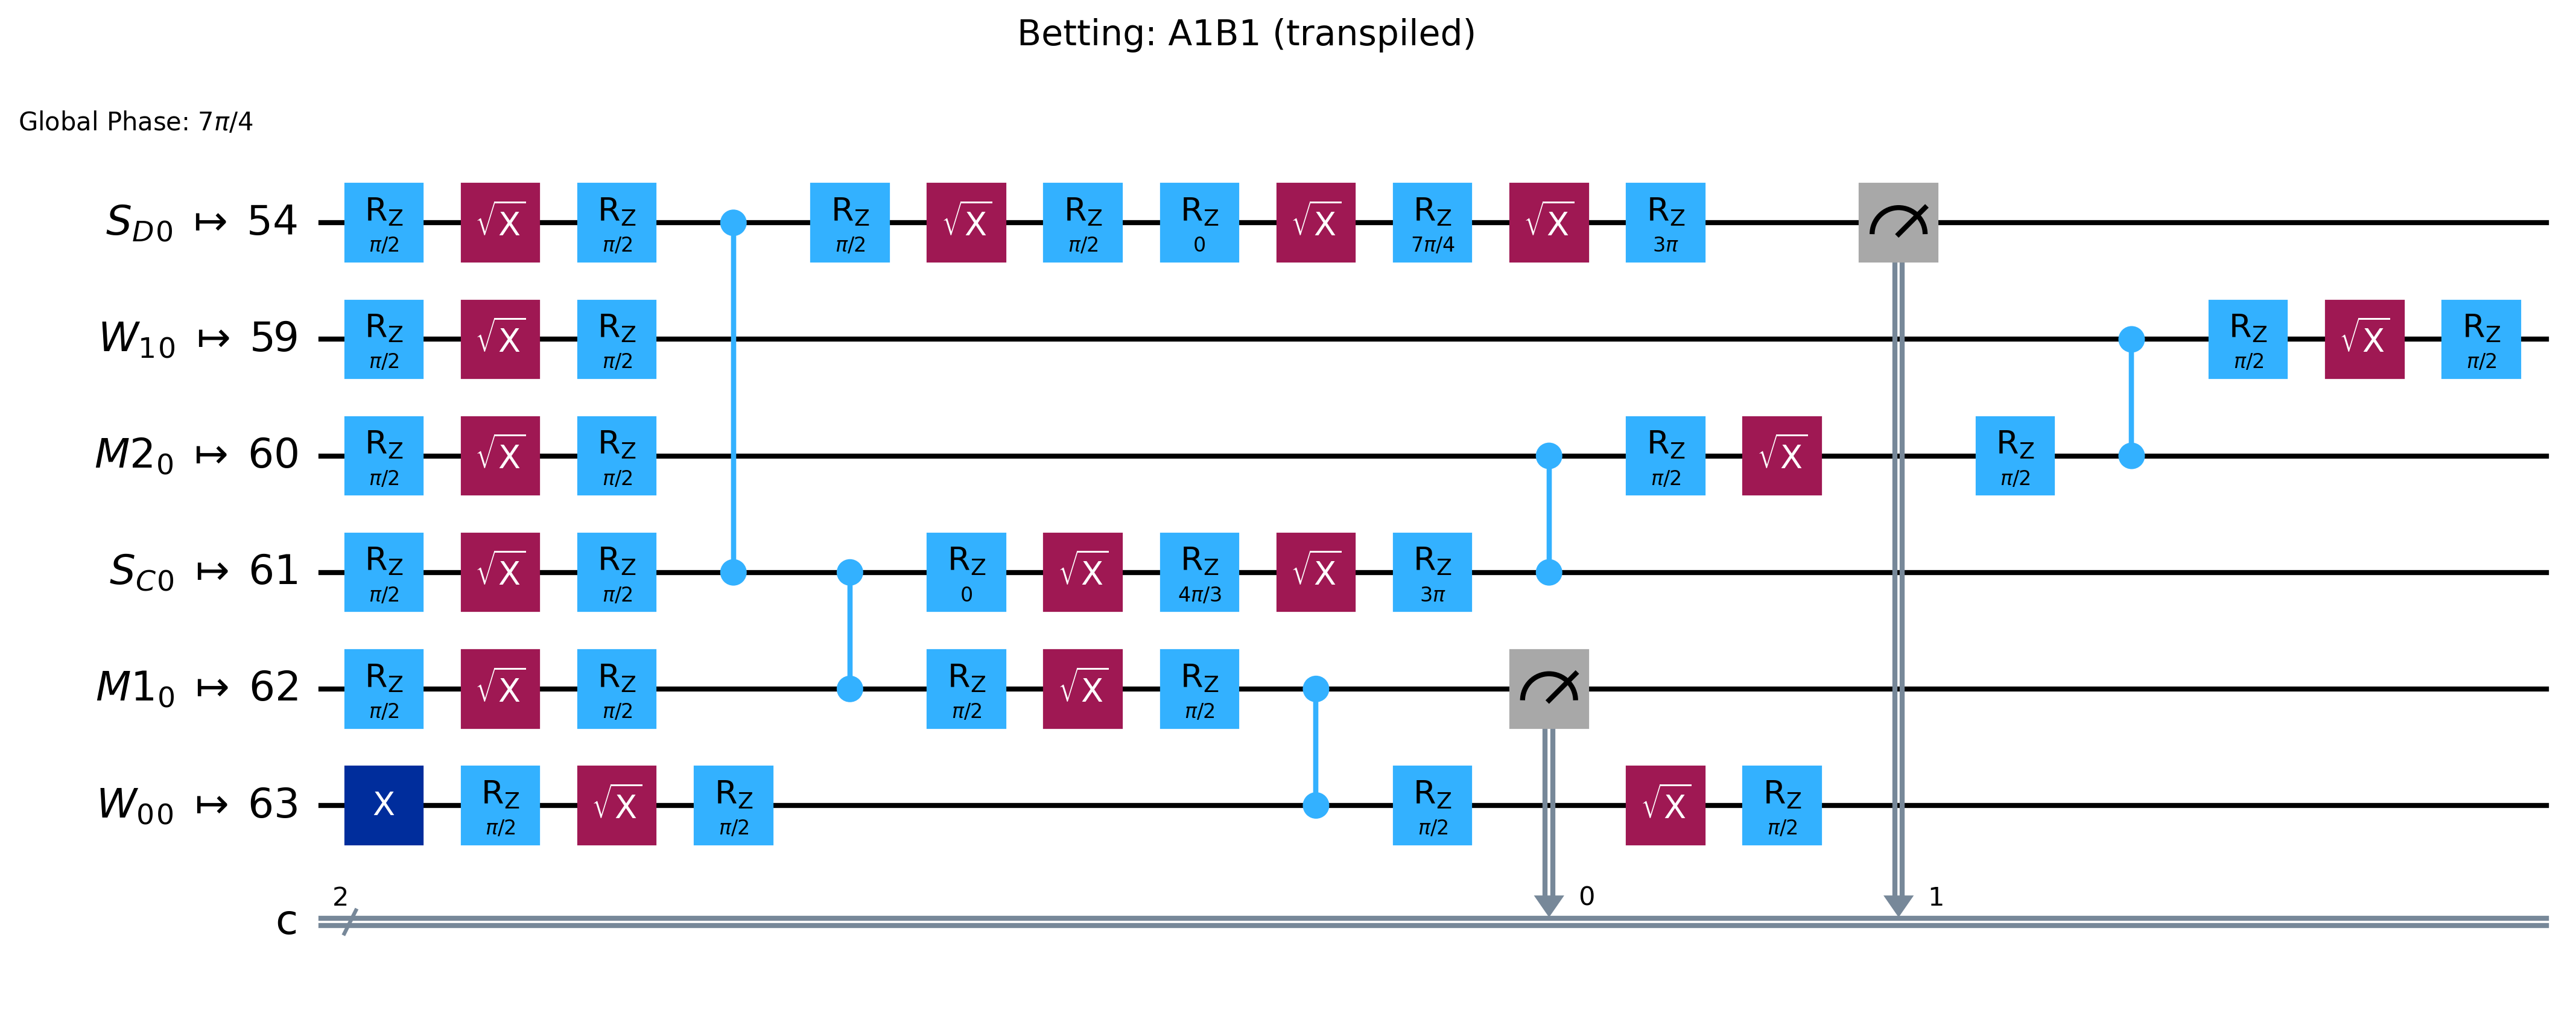

In [41]:
from pathlib import Path
from IPython.display import Image, display

# path to saved transpiled circuit (adjust if needed)
plot_path = PROJECT_ROOT / "results" / "plots_ibm_transpilation" / "transpiled" / "Betting" / "A1B1_depth18_cz5.png"
screenshot_path = PROJECT_ROOT / "data" / "IBM_torino_coupling_map" / "Screenshot" / "ibm_torino_screenshot.png"

display(Image(screenshot_path))
display(Image(plot_path))

# 4. Fake-hardware simulation
Before running on real hardware, we simulate our transpiled circuit using a noise model that is built by live calibration data from the IBM-Torino device. Note that these calibrations change over time, so the actual hardware run must be close to the simulation for the simulation to give actual approximations.
Using the Qiskit noise model called 'AerSimulator' a noise model is constructed using backend properties (gate errors, readout errors, T1/T2 times, etc.).

In [49]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
run_dir = PROJECT_ROOT / "data" / "data_fake_hardware" / "ibm_torino_20260223_151937"

path_json = run_dir / "fake_hardware_noise_sim.json"

with open(path_json, "r", encoding="utf-8") as f:
    run = json.load(f)

print(f"Fake hardware sim: {run['backend']}  ({run['timestamp']})\n")

for agent, d in run["agents"].items():
    E_line = ", ".join([f"{k}={v:.3f}" for k, v in d["E"].items()])
    print(f"{agent}:  S_SB = {d['S_SB']:.3f} ± {d['S_SB_err_1sigma_shotnoise']:.3f}")

Fake hardware sim: ibm_torino  (20260223_151937)

Reflex:  S_SB = 0.426 ± 0.020
Guessing:  S_SB = 0.250 ± 0.020
Betting:  S_SB = 0.520 ± 0.020


# 5. Real hardware run
If the Fake-hardware simulations show consistent violations of LF, a real hardware run can be performed.
IBM offers subscription accounts and trial accounts. Trial accounts provide runtime of 10min per month, which is enough for running circuits in this size (1000 shots equal 4s of runtime). One can directly connect to the IBM platform using an API key (which should not be shared and is not shared in this repo or notebook aswell).
The violations found for one run are shown below.

In [52]:
run_dir = PROJECT_ROOT / "data" / "data_real_hardware" / "ibm_torino_20260223_152224"

with open(run_dir / "processed_results.json", "r", encoding="utf-8") as f:
    processed = json.load(f)

print("Real hardware run: ibm_torino_20260223_152224")
print("shots = 1000\n")

for agent_name, d in processed.items():
    E_line = (
        f"A1B1={d['E_A1B1']:.3f}, A1B2={d['E_A1B2']:.3f}, "
        f"A2B1={d['E_A2B1']:.3f}, A2B2={d['E_A2B2']:.3f}"
    )
    print(f"{agent_name}:  S_SB = {d['S_SB']:.3f} ± {d['S_SB_err_1sigma']:.3f}")

Real hardware run: ibm_torino_20260223_152224
shots = 1000

Reflex:  S_SB = 0.580 ± 0.048
Guessing:  S_SB = 0.468 ± 0.050
Betting:  S_SB = 0.512 ± 0.049
